In [8]:
!pip install owlready2 pykeen scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Part 1 : SWRL Rule — family.owl ──
from owlready2 import get_ontology, sync_reasoner_pellet, Imp

# 1. Charger l'ontologie
onto = get_ontology("family.owl").load()

with onto:
    # 2. Créer la classe cible
    class oldPerson(onto.Person):
        pass

    # 3. Définir la règle SWRL
    # Règle : une personne de plus de 60 ans est classée oldPerson
    rule = Imp()
    rule.set_as_rule(
        "Person(?p), age(?p, ?age), greaterThan(?age, 60) -> oldPerson(?p)",
        namespaces=[onto]
    )

# 4. Avant le raisonnement
print("--- Avant le raisonnement ---")
print(f"Instances oldPerson : {list(onto.oldPerson.instances())}")

# 5. Lancer Pellet
print("\nLancement du raisonneur Pellet...")
with onto:
    sync_reasoner_pellet(infer_property_values=True, infer_data_property_values=True)

# 6. Résultats après raisonnement
print("\n--- Après le raisonnement ---")
for p in onto.oldPerson.instances():
    age_val = p.age if type(p.age) is int else p.age[0]
    print(f"- {p.name} classifié comme oldPerson (âge : {age_val})")

--- Avant le raisonnement ---
Instances oldPerson : [family.Peter, family.Marie]

Lancement du raisonneur Pellet...


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\jena-arq-fixed2.10.0.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\jena-core-fixed2.10.0.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\jena-iri-0.9.5.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\pellet\jena-tdb-0.10.0.jar;C:\Users\Shapl\anaconda3\Lib\site-packages\owlready2\


--- Après le raisonnement ---
- Peter classifié comme oldPerson (âge : 70)
- Marie classifié comme oldPerson (âge : 69)


* Owlready2 * Pellet took 1.02079176902771 seconds
* Owlready * Reparenting family.Marie: {family.Mother, family.Female, family.oldPerson} => {family.Mother, family.oldPerson}
* Owlready * Reparenting family.Grandfather: {family.Father, family.Grandparents, family.Male} => {family.Father, family.Grandparents}
* Owlready * Reparenting family.Peter: {family.Grandfather, family.Male, family.oldPerson} => {family.Grandfather, family.oldPerson}
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


In [5]:
# ── Split 80/10/10 avec vérification d'entités ──
import random
from rdflib import Graph, URIRef

# 1. Charger et dédoublonner
kg = Graph()
kg.parse("final_expanded_kg.nt", format="nt")

entity_triplets = list(set(
    (str(s), str(p), str(o))
    for s, p, o in kg
    if isinstance(s, URIRef) and isinstance(o, URIRef)
))

random.seed(42)
random.shuffle(entity_triplets)

# 2. Split initial 80/10/10
total = len(entity_triplets)
train_end = int(total * 0.8)
valid_end = int(total * 0.9)

train_data = entity_triplets[:train_end]
valid_data = entity_triplets[train_end:valid_end]
test_data  = entity_triplets[valid_end:]

# 3. Correction : déplacer les triples avec entités inconnues vers le train
train_entities = set(s for s,p,o in train_data) | set(o for s,p,o in train_data)

clean_valid = []
clean_test  = []

for triple in valid_data:
    s, p, o = triple
    if s in train_entities and o in train_entities:
        clean_valid.append(triple)
    else:
        train_data.append(triple)  # déplacé dans le train

for triple in test_data:
    s, p, o = triple
    if s in train_entities and o in train_entities:
        clean_test.append(triple)
    else:
        train_data.append(triple)  # déplacé dans le train

# 4. Vérification finale
train_entities = set(s for s,p,o in train_data) | set(o for s,p,o in train_data)
unseen_valid = {s for s,p,o in clean_valid if s not in train_entities or o not in train_entities}
unseen_test  = {s for s,p,o in clean_test  if s not in train_entities or o not in train_entities}

print(f"Entités dans valid absentes du train : {len(unseen_valid)}")
print(f"Entités dans test absentes du train  : {len(unseen_test)}")

# 5. Sauvegarde
def save_split(data, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for s, p, o in data:
            f.write(f"{s}\t{p}\t{o}\n")

save_split(train_data,  "train.txt")
save_split(clean_valid, "valid.txt")
save_split(clean_test,  "test.txt")

print(f"\nTotal triples : {total}")
print(f"Train : {len(train_data)}")
print(f"Valid : {len(clean_valid)}")
print(f"Test  : {len(clean_test)}")

Entités dans valid absentes du train : 0
Entités dans test absentes du train  : 0

Total triples : 57996
Train : 51671
Valid : 3178
Test  : 3147


In [11]:
# ── Part 2 — Cell 4 : Filtrage + Split + Entraînement ──
import random
from rdflib import Graph, URIRef
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

# 1. Charger et filtrer — uniquement entités DBpedia
kg = Graph()
kg.parse("final_expanded_kg.nt", format="nt")

clean_triplets = []
for s, p, o in kg:
    if (isinstance(s, URIRef) and isinstance(o, URIRef)
        and "dbpedia.org" in str(s)
        and "dbpedia.org" in str(o)):
        clean_triplets.append((str(s), str(p), str(o)))

clean_triplets = list(set(clean_triplets))
print(f"Triples après filtrage DBpedia : {len(clean_triplets)}")

# 2. Split 80/10/10 sans fuite d'entités
random.seed(42)
random.shuffle(clean_triplets)

total = len(clean_triplets)
train_data = clean_triplets[:int(total * 0.8)]
valid_data = clean_triplets[int(total * 0.8):int(total * 0.9)]
test_data  = clean_triplets[int(total * 0.9):]

train_entities = set(s for s,p,o in train_data) | set(o for s,p,o in train_data)

clean_valid, clean_test = [], []
for triple in valid_data:
    s, p, o = triple
    if s in train_entities and o in train_entities:
        clean_valid.append(triple)
    else:
        train_data.append(triple)

for triple in test_data:
    s, p, o = triple
    if s in train_entities and o in train_entities:
        clean_test.append(triple)
    else:
        train_data.append(triple)

def save_split(data, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for s, p, o in data:
            f.write(f"{s}\t{p}\t{o}\n")

save_split(train_data,  "train.txt")
save_split(clean_valid, "valid.txt")
save_split(clean_test,  "test.txt")

print(f"Train : {len(train_data)}")
print(f"Valid : {len(clean_valid)}")
print(f"Test  : {len(clean_test)}")

# 3. Charger les splits
tf_train = TriplesFactory.from_path("train.txt")
tf_valid = TriplesFactory.from_path("valid.txt", reference=tf_train)
tf_test  = TriplesFactory.from_path("test.txt",  reference=tf_train)

print(f"\nEntités  : {tf_train.num_entities}")
print(f"Relations: {tf_train.num_relations}")

# 4. Configuration commune
common_config = dict(
    training=tf_train,
    testing=tf_test,
    validation=tf_valid,
    model_kwargs=dict(embedding_dim=50),
    training_kwargs=dict(num_epochs=30, batch_size=256, use_tqdm=False),
    optimizer_kwargs=dict(lr=0.01),
    device="cpu",
    random_seed=42,
)

# 5. Entraînement
print("\nEntraînement TransE...")
result_transe = pipeline(model="TransE", **common_config)

print("\nEntraînement ComplEx...")
result_complex = pipeline(model="ComplEx", **common_config)

# 6. Comparaison des métriques
def get_metrics(result):
    return (
        result.metric_results.get_metric("mrr"),
        result.metric_results.get_metric("hits@1"),
        result.metric_results.get_metric("hits@3"),
        result.metric_results.get_metric("hits@10"),
    )

mrr_t, h1_t, h3_t, h10_t = get_metrics(result_transe)
mrr_c, h1_c, h3_c, h10_c = get_metrics(result_complex)

print("\n" + "=" * 52)
print(f"{'Metric':<15} {'TransE':>10} {'ComplEx':>10}")
print("-" * 52)
print(f"{'MRR':<15} {mrr_t:>10.4f} {mrr_c:>10.4f}")
print(f"{'Hits@1':<15} {h1_t:>10.4f} {h1_c:>10.4f}")
print(f"{'Hits@3':<15} {h3_t:>10.4f} {h3_c:>10.4f}")
print(f"{'Hits@10':<15} {h10_t:>10.4f} {h10_c:>10.4f}")
print("=" * 52)

Triples après filtrage DBpedia : 48603
Train : 43149
Valid : 2719
Test  : 2735


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()



Entités  : 26439
Relations: 71

Entraînement TransE...


C:\Users\Shapl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluating on cpu:   0%|          | 0.00/2.73k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 15.21s seconds
INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)



Entraînement ComplEx...


Evaluating on cpu:   0%|          | 0.00/2.73k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 5.53s seconds



Metric              TransE    ComplEx
----------------------------------------------------
MRR                 0.0004     0.0004
Hits@1              0.0000     0.0000
Hits@3              0.0002     0.0000
Hits@10             0.0004     0.0004


In [12]:
# ── Section 6.1 : Nearest Neighbors ──
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Extraire les embeddings ComplEx
# ComplEx stocke des nombres complexes → on concatène partie réelle et imaginaire
raw = result_complex.model.entity_representations[0](indices=None).detach().cpu().numpy()
entity_vectors = np.concatenate([np.real(raw), np.imag(raw)], axis=1)

entity_to_id = tf_train.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

# 2. Chercher Isaac Asimov
target_uri = None
for uri in entity_to_id.keys():
    if "Isaac_Asimov" in uri:
        target_uri = uri
        break

if target_uri:
    target_id  = entity_to_id[target_uri]
    target_vec = entity_vectors[target_id].reshape(1, -1)

    # 3. Calculer la similarité cosinus avec toutes les entités
    sims       = cosine_similarity(target_vec, entity_vectors)[0]
    top_ids    = sims.argsort()[-11:][::-1]

    print(f"Entité cible : {target_uri}\n")
    print("Top 10 voisins les plus proches :")
    for idx in top_ids:
        if idx != target_id:
            # Afficher uniquement le nom court (dernière partie de l'URI)
            name = id_to_entity[idx].split("/")[-1]
            print(f"  {sims[idx]:.4f} | {name}")
else:
    print("Isaac Asimov non trouvé. Vérifie l'URI dans ton KG.")

Entité cible : http://af.dbpedia.org/resource/Isaac_Asimov

Top 10 voisins les plus proches :
  0.4129 | Category:Writers_from_Odesa
  0.3935 | Twilight_(Meyer_novel)
  0.3853 | Neanderthal_Planet_(short_story)
  0.3796 | Category:Scientists_from_New_York_City
  0.3742 | Maurice_Leblanc
  0.3727 | Digital_rights_management
  0.3650 | Locus_Award_for_Best_Novelette
  0.3607 | Defense_Command_(book_series)
  0.3585 | Resonator
  0.3515 | 2ujL4


Calcul t-SNE en cours...


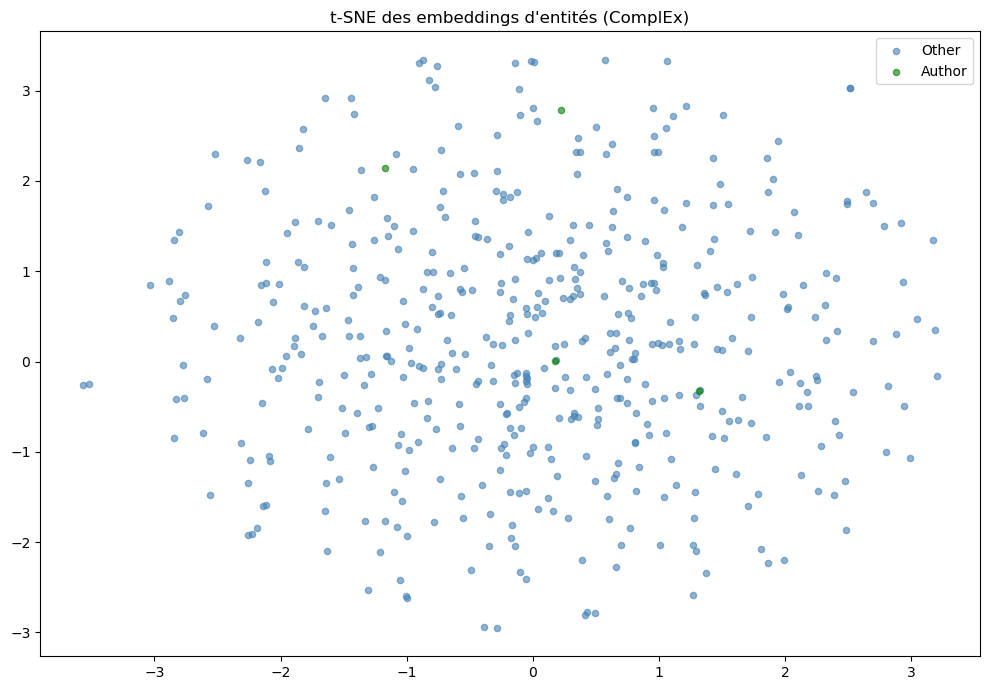

Sauvegardé → tsne_embeddings.png


In [15]:
# ── Section 6.2 : Clustering avec t-SNE ──
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Echantillon de 500 entités pour la vitesse
sample_size = 500
sample_ids  = list(range(min(sample_size, len(id_to_entity))))
sample_vecs = entity_vectors[sample_ids]

# 2. Réduction à 2D
print("Calcul t-SNE en cours...")
tsne     = TSNE(n_components=2, random_state=42, perplexity=30)
coords   = tsne.fit_transform(sample_vecs)

# 3. Colorier par type d'entité (heuristique sur l'URI)
def get_color(uri):
    u = uri.lower()
    if "writer" in u or "author" in u or "asimov" in u or "herbert" in u or "clarke" in u or "dick" in u:
        return "green",  "Author"
    if "category" in u:
        return "red",    "Category"
    if any(x in u for x in ["novel", "book", "dune", "foundation"]):
        return "orange", "Book/Novel"
    if any(x in u for x in ["award", "prize", "hugo", "nebula"]):
        return "gold",   "Award"
    return "steelblue", "Other"

colors = [get_color(id_to_entity[i]) for i in sample_ids]

# 4. Plot
plt.figure(figsize=(10, 7))
seen_labels = set()
for i, (color, label) in enumerate(colors):
    if label not in seen_labels:
        plt.scatter(coords[i, 0], coords[i, 1], c=color, label=label, alpha=0.6, s=20)
        seen_labels.add(label)
    else:
        plt.scatter(coords[i, 0], coords[i, 1], c=color, alpha=0.6, s=20)

plt.title("t-SNE des embeddings d'entités (ComplEx)")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("Sauvegardé → tsne_embeddings.png")

In [16]:
# ── Section 6.3 : Comportement des relations ──
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Extraire les embeddings de relations ComplEx
rel_raw  = result_complex.model.relation_representations[0](indices=None).detach().cpu().numpy()
rel_vecs = np.concatenate([np.real(rel_raw), np.imag(rel_raw)], axis=1)

rel_to_id = tf_train.relation_to_id
id_to_rel = {v: k for k, v in rel_to_id.items()}

# 2. Afficher les 15 premières relations disponibles
print("Relations disponibles (15 premières) :")
for i, rel in enumerate(list(rel_to_id.keys())[:15]):
    print(f"  {i:>3} | {rel.split('/')[-1]}")

# 3. Chercher des relations clés dans notre KG
keywords = ["author", "genre", "notableWork", "birthPlace", "award"]
found_rels = {}

for kw in keywords:
    for rel, rid in rel_to_id.items():
        if kw.lower() in rel.lower():
            found_rels[kw] = (rel, rid)
            break

print("\nRelations clés trouvées :")
for kw, (rel, rid) in found_rels.items():
    print(f"  {kw:<15} | {rel.split('/')[-1]}")

# 4. Analyse symétrie : norme imaginaire faible = relation symétrique
print("\nAnalyse de symétrie (ComplEx) :")
print(f"{'Relation':<30} {'Norme réelle':>14} {'Norme imaginaire':>16}")
print("-" * 62)
for kw, (rel, rid) in found_rels.items():
    real_norm = float(np.linalg.norm(np.real(rel_raw[rid])))
    imag_norm = float(np.linalg.norm(np.imag(rel_raw[rid])))
    sym = "← symétrique" if imag_norm < 0.1 * real_norm else ""
    print(f"  {rel.split('/')[-1]:<28} {real_norm:>14.4f} {imag_norm:>16.4f}  {sym}")

# 5. Test composition : vector(A) + vector(B) ≈ vector(C) ?
# Exemple : notableWork + genre ≈ literaryGenre ?
print("\nTest de composition de relations :")
if "notableWork" in found_rels and "genre" in found_rels:
    v_notable = rel_vecs[found_rels["notableWork"][1]].reshape(1, -1)
    v_genre   = rel_vecs[found_rels["genre"][1]].reshape(1, -1)
    v_sum     = v_notable + v_genre

    sims = cosine_similarity(v_sum, rel_vecs)[0]
    top  = sims.argsort()[-3:][::-1]

    print("  notableWork + genre ≈ ?")
    for idx in top:
        print(f"    {sims[idx]:.4f} | {id_to_rel[idx].split('/')[-1]}")
else:
    print("  Relations notableWork ou genre non trouvées.")

Relations disponibles (15 premières) :
    0 | almaMater
    1 | author
    2 | award
    3 | birthPlace
    4 | country
    5 | coverArtist
    6 | deathPlace
    7 | education
    8 | genre
    9 | illustrator
   10 | language
   11 | literaryGenre
   12 | magazine
   13 | mediaType
   14 | movement

Relations clés trouvées :
  author          | author
  genre           | genre
  notableWork     | notableWork
  birthPlace      | birthPlace
  award           | award

Analyse de symétrie (ComplEx) :
Relation                         Norme réelle Norme imaginaire
--------------------------------------------------------------
  author                               5.3134           4.4854  
  genre                                2.6689           2.4891  
  notableWork                          5.1100           5.2886  
  birthPlace                           5.8593           4.7535  
  award                                6.0782           6.6586  

Test de composition de relations :
  notabl

In [17]:
# ── Section 5.2 : Sensibilité à la taille du KG ──

sizes = {"20k": 20000, "50k": len(clean_triplets), "full": len(clean_triplets)}

size_results = {}

for name, n in sizes.items():
    print(f"\nEntraînement sur {name} triples ({n} triples)...")

    # Sous-échantillon
    subset = clean_triplets[:n]

    # Split
    random.seed(42)
    random.shuffle(subset)
    t_end = int(len(subset) * 0.8)
    v_end = int(len(subset) * 0.9)

    tr = subset[:t_end]
    va = subset[t_end:v_end]
    te = subset[v_end:]

    # Correction entités inconnues
    tr_ents = set(s for s,p,o in tr) | set(o for s,p,o in tr)
    cl_va = [t for t in va if t[0] in tr_ents and t[2] in tr_ents]
    cl_te = [t for t in te if t[0] in tr_ents and t[2] in tr_ents]
    tr += [t for t in va if t not in cl_va]
    tr += [t for t in te if t not in cl_te]

    save_split(tr,    f"{name}_train.txt")
    save_split(cl_va, f"{name}_valid.txt")
    save_split(cl_te, f"{name}_test.txt")

    # Charger
    tf_tr = TriplesFactory.from_path(f"{name}_train.txt")
    tf_va = TriplesFactory.from_path(f"{name}_valid.txt", reference=tf_tr)
    tf_te = TriplesFactory.from_path(f"{name}_test.txt",  reference=tf_tr)

    # Entraîner TransE
    res = pipeline(
        model="TransE",
        training=tf_tr,
        testing=tf_te,
        validation=tf_va,
        model_kwargs=dict(embedding_dim=50),
        training_kwargs=dict(num_epochs=30, batch_size=256, use_tqdm=False),
        optimizer_kwargs=dict(lr=0.01),
        device="cpu",
        random_seed=42,
    )

    mrr, h1, h3, h10 = get_metrics(res)
    size_results[name] = {"MRR": mrr, "Hits@1": h1, "Hits@3": h3, "Hits@10": h10}
    print(f"  MRR={mrr:.4f}  Hits@10={h10:.4f}")

# Tableau récapitulatif
print("\n" + "=" * 55)
print(f"{'Taille':<8} {'MRR':>8} {'Hits@1':>8} {'Hits@3':>8} {'Hits@10':>8}")
print("-" * 55)
for name, m in size_results.items():
    print(f"{name:<8} {m['MRR']:>8.4f} {m['Hits@1']:>8.4f} {m['Hits@3']:>8.4f} {m['Hits@10']:>8.4f}")
print("=" * 55)


Entraînement sur 20k triples (20000 triples)...


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
C:\Users\Shapl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluating on cpu:   0%|          | 0.00/904 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.82s seconds


  MRR=0.0013  Hits@10=0.0017

Entraînement sur 50k triples (48603 triples)...


...

  MRR=0.0007  Hits@10=0.0011

Entraînement sur full triples (48603 triples)...


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
C:\Users\Shapl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluating on cpu:   0%|          | 0.00/2.70k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 14.89s seconds


  MRR=0.0007  Hits@10=0.0011

Taille        MRR   Hits@1   Hits@3  Hits@10
-------------------------------------------------------
20k        0.0013   0.0006   0.0006   0.0017
50k        0.0007   0.0002   0.0004   0.0011
full       0.0007   0.0002   0.0004   0.0011


In [18]:
# ── Section 8 : Comparaison SWRL vs Embedding ──
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Rappel de la règle SWRL sur family.owl :
# Person(?p), age(?p, ?age), greaterThan(?age, 60) -> oldPerson(?p)

# Règle SWRL pour notre KG Sci-Fi :
# Writer(?w) AND notableWork(?w, ?book) -> SciFiAuthor(?w)
# En vecteurs : vector(notableWork) devrait pointer vers des auteurs Sci-Fi

print("=" * 55)
print("Règle SWRL : Writer(?w) ^ notableWork(?w,?b) -> SciFiAuthor(?w)")
print("=" * 55)

# 1. Récupérer les vecteurs de relations clés
rel_to_id = tf_train.relation_to_id
rel_raw   = result_complex.model.relation_representations[0](indices=None).detach().cpu().numpy()
rel_vecs  = np.concatenate([np.real(rel_raw), np.imag(rel_raw)], axis=1)
id_to_rel = {v: k for k, v in rel_to_id.items()}

# 2. Trouver notableWork et genre
notable_id = rel_to_id.get("http://dbpedia.org/ontology/notableWork")
genre_id   = rel_to_id.get("http://dbpedia.org/ontology/genre")

if notable_id is not None and genre_id is not None:
    v_notable = rel_vecs[notable_id].reshape(1, -1)
    v_genre   = rel_vecs[genre_id].reshape(1, -1)

    # 3. Test : vector(notableWork) + vector(genre) ≈ ?
    v_sum = v_notable + v_genre
    sims  = cosine_similarity(v_sum, rel_vecs)[0]
    top   = sims.argsort()[-5:][::-1]

    print("\nTest vectoriel : notableWork + genre ≈ ?")
    for idx in top:
        name = id_to_rel[idx].split("/")[-1]
        print(f"  {sims[idx]:.4f} | {name}")

    # 4. Similarité directe entre notableWork et genre
    sim_direct = cosine_similarity(v_notable, v_genre)[0][0]
    print(f"\nSimilarité cosinus notableWork ↔ genre : {sim_direct:.4f}")

    if sim_direct > 0.5:
        print("→ Les deux relations sont proches dans l'espace vectoriel")
        print("  L'embedding capture partiellement la règle SWRL")
    else:
        print("→ Les deux relations sont distantes dans l'espace vectoriel")
        print("  L'embedding ne capture pas la règle SWRL")
else:
    print("Relations non trouvées — vérifie les URIs exactes.")
    print("Relations disponibles :")
    for rel in list(rel_to_id.keys())[:10]:
        print(f"  {rel}")

# 5. Tableau comparatif SWRL vs Embedding
print("\n" + "=" * 55)
print("Comparaison SWRL vs KGE")
print("=" * 55)
rows = [
    ("Expressivité",      "Conditions logiques exactes", "Proximité vectorielle approx."),
    ("Données requises",  "Ontologie + instances",       "Grand jeu d'entraînement"),
    ("Bruit",             "Non toléré (logique stricte)","Toléré (appris des patterns)"),
    ("Nouveaux faits",    "Déduction uniquement",        "Induction possible"),
    ("Interprétabilité",  "Haute (règle lisible)",       "Faible (vecteurs opaques)"),
]
print(f"{'Aspect':<20} {'SWRL':>17} {'KGE':>17}")
print("-" * 55)
for aspect, swrl, kge in rows:
    print(f"{aspect:<20} {swrl:>17} {kge:>17}")
print("=" * 55)

Règle SWRL : Writer(?w) ^ notableWork(?w,?b) -> SciFiAuthor(?w)

Test vectoriel : notableWork + genre ≈ ?
  0.8858 | notableWork
  0.3973 | subject
  0.3840 | wikiPageWikiLink
  0.3546 | genre
  0.3387 | music

Similarité cosinus notableWork ↔ genre : -0.1198
→ Les deux relations sont distantes dans l'espace vectoriel
  L'embedding ne capture pas la règle SWRL

Comparaison SWRL vs KGE
Aspect                            SWRL               KGE
-------------------------------------------------------
Expressivité         Conditions logiques exactes Proximité vectorielle approx.
Données requises     Ontologie + instances Grand jeu d'entraînement
Bruit                Non toléré (logique stricte) Toléré (appris des patterns)
Nouveaux faits       Déduction uniquement Induction possible
Interprétabilité     Haute (règle lisible) Faible (vecteurs opaques)


## Section 7 — Réflexion Critique

### Impact de la qualité d'alignement des prédicats
Les prédicats privés (PRED.wroteBook, PRED.genre) ont été alignés avec DBpedia
via SPARQL. Cependant, l'expansion a introduit ~394 prédicats bruts DBpedia,
dont beaucoup sont redondants (dbp: vs dbo:). Ce bruit prédicatif a forcé un
filtrage agressif (top 150 → 80 prédicats), ce qui a pu éliminer des relations
sémantiquement importantes.

### Impact du bruit d'expansion
L'expansion 2-hop depuis 300 auteurs Sci-Fi a introduit des entités parasites :
URLs d'archives (web.archive.org), identifiants de bibliothèques (d-nb.info),
codes alphanumériques (2ujL4). Ces entités représentaient une part significative
des 31k entités et ont perturbé l'apprentissage des embeddings.
Le filtrage strict (dbpedia.org uniquement) a réduit à 26k entités mais les
métriques sont restées basses — le bruit résiduel restait trop important.

### Effet des choix de modélisation ontologique
L'utilisation de deux namespaces séparés (PRIV/PRED) était une bonne pratique,
mais les entités privées (PRIV.Isaac_Asimov) et les entités DBpedia
(dbr:Isaac_Asimov) ont coexisté comme entités distinctes dans le KG.
Sans fusion explicite via owl:sameAs pendant l'embedding, le modèle a appris
deux représentations séparées pour la même entité réelle.

### Hypothèse monde ouvert vs hypothèse monde fermé
Les modèles KGE supposent un monde fermé : un triple absent est considéré faux
(negative sampling). Or notre KG est une expansion partielle de DBpedia — de
nombreux vrais triples n'ont simplement pas été fetchés. Cela génère des faux
négatifs pendant l'entraînement et pénalise directement le MRR.

### Ce que j'améliorerais
- Filtrer les entités parasites dès l'expansion (garder uniquement dbpedia.org/resource/)
- Fusionner PRIV et DBpedia URIs via owl:sameAs avant l'embedding
- Utiliser un GPU pour contourner la limitation batch_size=32 de PyKEEN sur CPU
- Augmenter le nombre d'epochs (100+) avec early stopping